# UCI HAR: Masked Pretraining vs Baseline

Does masked pretraining improve activity recognition with 100% versus 10% of the training labels?

This notebook runs the complete four-way comparison: two label fractions, each with a randomly initialised baseline and a pretrained CNN. The four steps are pretraining, reconstruction curves, classification training, and one results table. Run `02_data_preprocessing.ipynb` first. All results are computed here; no previous model or manually copied score is used.

## 1. Masked Pretraining

Use all training sensor signals for pretraining; activity labels are not used. The existing subject-based split and standardisation are preserved.

Each window contains 16 blocks of 8 time steps. Hide 5 blocks (31.25%) across all nine channels by replacing their values with zero. Training masks change each batch; validation masks stay fixed. The original values supply the reconstruction targets.

In [27]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "uci_har_preprocessed.npz"

with np.load(DATA_PATH, allow_pickle=False) as data:
    X_train = data["X_train"]
    X_validation = data["X_validation"]
    sensor_channels = data["sensor_channels"]
    assert set(data["subject_train"]).isdisjoint(set(data["subject_validation"]))

RANDOM_SEED = 42
LABEL_FRACTIONS = (1.0, 0.10)
BATCH_SIZE = 64
MAX_EPOCHS = 50
LEARNING_RATE = 0.001
BLOCK_LENGTH = 8
TIME_STEPS, NUMBER_OF_CHANNELS = X_train.shape[1:]
NUMBER_OF_BLOCKS = TIME_STEPS // BLOCK_LENGTH
MASKED_BLOCKS = 5

keras.utils.set_random_seed(RANDOM_SEED)
tf.config.experimental.enable_op_determinism()
assert X_train.shape[1:] == X_validation.shape[1:] == (128, 9)


In [28]:
def make_fixed_masks(number_of_samples, seed):
    generator = np.random.default_rng(seed)
    scores = generator.random((number_of_samples, NUMBER_OF_BLOCKS))
    selected_blocks = np.argsort(scores, axis=1)[:, :MASKED_BLOCKS]

    block_masks = np.zeros(
        (number_of_samples, NUMBER_OF_BLOCKS), dtype=np.float32
    )
    block_masks[np.arange(number_of_samples)[:, None], selected_blocks] = 1.0
    return np.repeat(block_masks, BLOCK_LENGTH, axis=1)[..., None]


validation_masks = make_fixed_masks(len(X_validation), RANDOM_SEED + 1)
X_validation_masked = X_validation * (1.0 - validation_masks)



def mask_training_batch(clean_signals):
    batch_size = tf.shape(clean_signals)[0]
    scores = tf.random.uniform((batch_size, NUMBER_OF_BLOCKS))
    ranks = tf.argsort(tf.argsort(scores, axis=1), axis=1)
    block_masks = tf.cast(ranks < MASKED_BLOCKS, tf.float32)
    masks = tf.repeat(block_masks, repeats=BLOCK_LENGTH, axis=1)[..., None]

    masked_signals = clean_signals * (1.0 - masks)
    packed_targets = tf.concat([clean_signals, masks], axis=-1)
    return masked_signals, packed_targets


training_dataset = (
    tf.data.Dataset.from_tensor_slices(X_train)
    .shuffle(len(X_train), seed=RANDOM_SEED, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .map(mask_training_batch, num_parallel_calls=1)
    .prefetch(1)
)

validation_targets = np.concatenate([X_validation, validation_masks], axis=-1)
validation_dataset = tf.data.Dataset.from_tensor_slices(
    (X_validation_masked, validation_targets)
).batch(BATCH_SIZE)

The encoder has the same convolutional layers as the baseline. A decoder restores the signal shape:

`128 x 9 -> Encoder -> 64 x 128 -> Decoder -> 128 x 9`

Only hidden values contribute to mean squared error (MSE). The loss receives nine clean target channels plus one mask channel; these clean targets are never model inputs. Early stopping restores the weights with the lowest validation loss.

In [29]:
def build_encoder():
    return keras.Sequential([
        layers.Input(shape=(128, 9)),
        layers.Conv1D(64, 5, padding="same", activation="relu"),
        layers.MaxPooling1D(2),
        layers.Conv1D(128, 3, padding="same", activation="relu"),
    ], name="encoder")


encoder = build_encoder()
decoder = keras.Sequential([
    layers.Input(shape=(64, 128)),
    layers.Conv1D(64, 3, padding="same", activation="relu"),
    layers.UpSampling1D(2),
    layers.Conv1D(32, 5, padding="same", activation="relu"),
    layers.Conv1D(9, 1, padding="same"),
], name="decoder")
autoencoder = keras.Sequential([encoder, decoder], name="masked_autoencoder")


def masked_mse(targets, predictions):
    clean, mask = targets[..., :9], targets[..., 9:]
    error = tf.reduce_sum(tf.square(clean - predictions) * mask, axis=(1, 2))
    count = tf.reduce_sum(mask, axis=(1, 2)) * 9
    return tf.math.divide_no_nan(error, count)


def early_stopping():
    return keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=8, restore_best_weights=True
    )


autoencoder.compile(
    optimizer=keras.optimizers.Adam(LEARNING_RATE), loss=masked_mse
)
pretraining_history = autoencoder.fit(
    training_dataset,
    validation_data=validation_dataset,
    epochs=MAX_EPOCHS,
    callbacks=[early_stopping()],
    verbose=0,
)

# Keep a separate snapshot so classifier fine-tuning cannot alter it.
pretrained_weights = [weight.copy() for weight in encoder.get_weights()]

D:\Lunacia\Machine Learning\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


## 2. Actual and Reconstructed Signals

Compare the original signal with the model's reconstruction for one fixed validation sample. Predictions are shown only inside the shaded hidden regions; outside those regions the original visible input is retained. All values are in standardised units. This plot illustrates reconstruction, not classification performance.

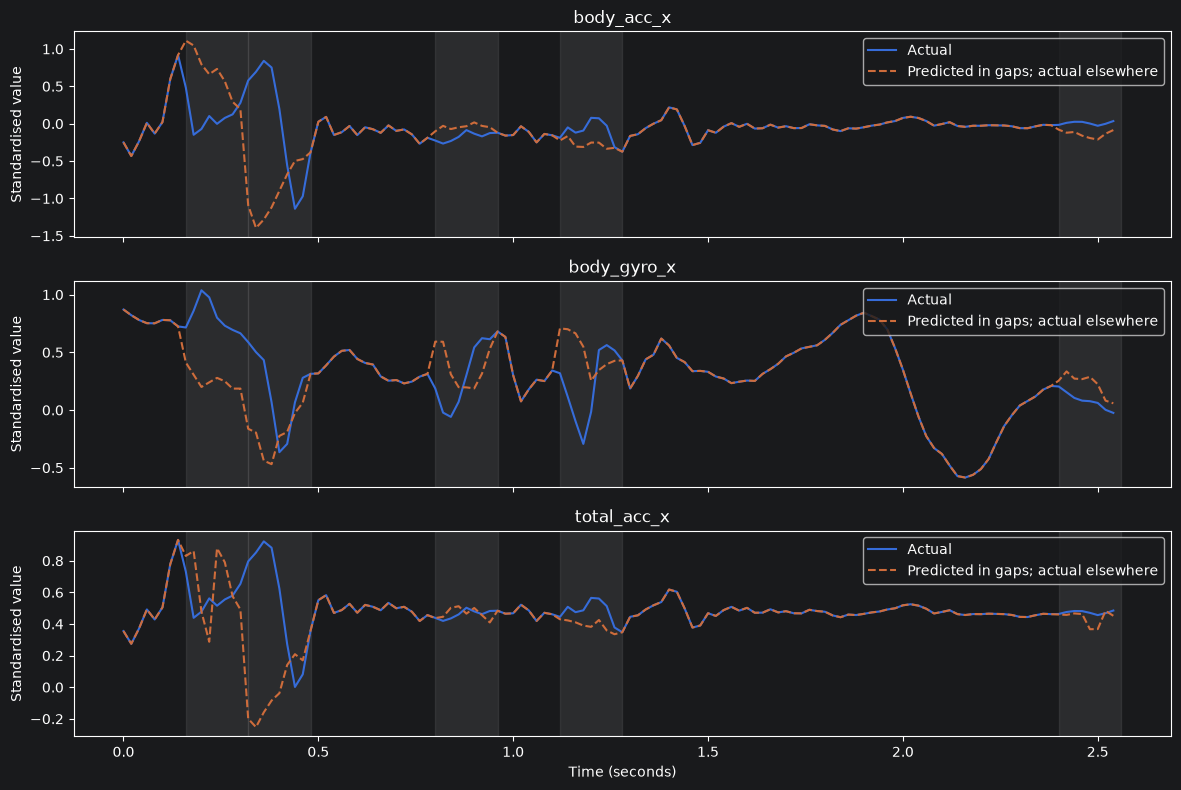

In [30]:
SAMPLE_INDEX = 0
mask = validation_masks[SAMPLE_INDEX]
prediction = autoencoder.predict(
    X_validation_masked[SAMPLE_INDEX:SAMPLE_INDEX + 1], verbose=0
)[0]
completed_signal = X_validation_masked[SAMPLE_INDEX] + prediction * mask
time_seconds = np.arange(TIME_STEPS) / 50

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, channel in zip(axes, [0, 3, 6]):
    ax.plot(time_seconds, X_validation[SAMPLE_INDEX, :, channel], label="Actual")
    ax.plot(time_seconds, completed_signal[:, channel], "--",
            label="Predicted in gaps; actual elsewhere")
    for start in range(0, TIME_STEPS, BLOCK_LENGTH):
        if mask[start, 0] == 1:
            ax.axvspan(start / 50, (start + BLOCK_LENGTH) / 50,
                       color="grey", alpha=0.18)
    ax.set_title(str(sensor_channels[channel]))
    ax.set_ylabel("Standardised value")
    ax.legend(loc="upper right")
axes[-1].set_xlabel("Time (seconds)")
plt.tight_layout()
plt.show()

## 3. Train the Classification CNNs

Both CNNs use the architecture from Notebook 03:

`Encoder -> GlobalAveragePooling -> Dense(64, ReLU) -> Dropout(0.3) -> Dense(6, Softmax)`

Run two conditions: all training labels, and approximately 10%. The smaller subset is selected once by stratified sampling. Within each condition, both models receive exactly the same complete, unmasked training signals and labels.

Each model is built from scratch with its own weights and optimizer. Classification heads start identically; only the pretrained CNN receives a copy of the encoder weights learned in Step 1. All layers are fine-tuned. Both conditions reuse the same pretraining snapshot, so one classifier cannot change another's starting weights.

Learning rate, batch size, epoch limit and early-stopping rule are matched. The full validation set and its labels are used for both conditions; 10% refers only to classification training labels. Pretraining uses all training signals and incurs additional training effort. The full-label baseline is rerun here rather than taking an older score from Notebook 03.

In [31]:
with np.load(DATA_PATH, allow_pickle=False) as data:
    y_train = data["y_train"]
    y_validation = data["y_validation"]
    activity_names = data["activity_names"]


# One shared index set per condition; do not change the pretraining data.
labelled_subsets = {}
for fraction in LABEL_FRACTIONS:
    if fraction == 1.0:
        indices = np.arange(len(X_train))
    else:
        indices, _ = train_test_split(
            np.arange(len(X_train)),
            train_size=fraction,
            stratify=y_train,
            random_state=RANDOM_SEED,
        )
    indices = np.sort(indices)
    assert len(np.unique(indices)) == len(indices)
    assert np.array_equal(np.unique(y_train[indices]), np.unique(y_train))
    labelled_subsets[fraction] = indices


def build_classifier(encoder_weights=None):
    keras.utils.set_random_seed(RANDOM_SEED)
    feature_extractor = build_encoder()
    model = keras.Sequential([
        feature_extractor,
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(6, activation="softmax"),
    ])
    if encoder_weights is not None:
        feature_extractor.set_weights(encoder_weights)
    model.compile(
        optimizer=keras.optimizers.Adam(LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


models = {}
classification_histories = {}
for fraction, indices in labelled_subsets.items():
    baseline_cnn = build_classifier()
    pretrained_cnn = build_classifier(pretrained_weights)

    # Verify matched architecture and identical initial classification heads.
    assert baseline_cnn.count_params() == pretrained_cnn.count_params() == 36294
    for baseline_layer, pretrained_layer in zip(
        baseline_cnn.layers[1:], pretrained_cnn.layers[1:]
    ):
        for left, right in zip(baseline_layer.get_weights(), pretrained_layer.get_weights()):
            np.testing.assert_array_equal(left, right)

    for name, model in [("Baseline", baseline_cnn), ("Masked pretraining", pretrained_cnn)]:
        keras.utils.set_random_seed(RANDOM_SEED)
        key = (fraction, name)
        models[key] = model
        classification_histories[key] = model.fit(
            X_train[indices], y_train[indices],
            validation_data=(X_validation, y_validation),
            epochs=MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[early_stopping()],
            verbose=0,
        )

## 4. Compare the Results

Load test signals only after all four classifiers finish training. Every model is evaluated on the same complete, unmasked signals from unseen test subjects. Compare accuracy and macro F1 within each label fraction; macro F1 gives each activity equal weight. Test loss is classification cross-entropy, not reconstruction MSE.

The table records the actual labelled sample count and the selected epoch (minimum validation loss) for each model. All training settings are fixed before this evaluation step; checkpoint selection uses validation loss. This is an exploratory single-seed comparison on a test split inspected in earlier runs, so small differences do not establish a stable benefit or statistical significance.

In [32]:
with np.load(DATA_PATH, allow_pickle=False) as data:
    X_test, y_test = data["X_test"], data["y_test"]
    assert set(data["subject_test"]).isdisjoint(
        set(data["subject_train"]) | set(data["subject_validation"])
    )

rows = []
for (fraction, name), model in models.items():
    loss, accuracy = model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=0)
    predictions = np.argmax(model.predict(X_test, batch_size=BATCH_SIZE, verbose=0), axis=1)
    rows.append({
        "Training labels": f"{fraction:.0%}",
        "Model": name,
        "Samples": len(labelled_subsets[fraction]),
        "Selected epoch": int(np.argmin(classification_histories[(fraction, name)].history["val_loss"]) + 1),
        "Test loss": loss,
        "Accuracy": accuracy,
        "Macro F1": f1_score(y_test, predictions, average="macro"),
    })

comparison = pd.DataFrame(rows).set_index(["Training labels", "Model"])
print(comparison.round(4).to_string())

                                    Samples  Selected epoch  Test loss  Accuracy  Macro F1
Training labels Model                                                                     
100%            Baseline               5952               3     0.3217    0.9043    0.9038
                Masked pretraining     5952               3     0.3806    0.9036    0.9028
10%             Baseline                595              22     0.3623    0.8850    0.8845
                Masked pretraining      595              19     0.3708    0.8901    0.8896
